In [122]:
import os
# import sys; sys.path.append("/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps")

# merge bmat files

In [123]:
!python /lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/BioinformaticAnalysisTools/target_deep_sequencing_tools/get_target-seq_info.py -h

usage: get_target-seq_info.py [-h] --bmat_folder BMAT_FOLDER [--out OUT]

optional arguments:
  -h, --help            show this help message and exit
  --bmat_folder BMAT_FOLDER
                        All the bmat file should be formated as: TargetSeq-
                        TREATMENT_x_REP_x_REGIONID_x_CUTOFF_x.bmat.gz and put
                        in this folder.
  --out OUT             The path to put out csv file.


In [127]:
!python /lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/BioinformaticAnalysisTools/target_deep_sequencing_tools/get_target-seq_info.py \
    --bmat_folder ../bmat \
    --out 2022-05-24_batch2_HEK4.bmats.csv

INFO  @ 2022-05-24 21:01:45: script done. 


# analysis

In [128]:
# !pip install datar plotnine seaborn openpyxl

In [215]:
# %% imports and settings
from pandarallel import pandarallel
import datar.all as r
from datar import f
import plotnine as p9
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set()
pd.set_option("max_colwidth", 250)  # column最大宽度
pd.set_option("display.width", 250)  # dataframe宽度
pd.set_option("display.max_columns", None)  # column最大显示数
pd.set_option("display.max_rows", 50)  # row最大显示数
pandarallel.initialize()  # 多线程设置，默认使用全部核心 nb_workers=24


# %% os.chdir
# os.chdir(    "/Users/zhaohuanan/NutstoreFiles/MyNutstore/Scientific_research/2021_DdCBE_topic/TargetSeq/20220305_TargetSeq_bmat_alldone_add_v2")

INFO: Pandarallel will run on 16 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [130]:
df = pd.read_csv('2022-05-24_batch2_HEK4.bmats.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())

  treatment   rep  cutoff   region_id ref_base  relative_pos                                                              bmat_name  total_count mut_base  mut_count
0       ABE  rep1       3  HK4-AOut-3        G             1  ../TargetSeq-TREATMENT_ABE_REP_1_CUTOFF_3_REGIONID_HK4-AOut-3.bmat.gz        93202        A          0
1       ABE  rep1       3  HK4-AOut-3        G             2  ../TargetSeq-TREATMENT_ABE_REP_1_CUTOFF_3_REGIONID_HK4-AOut-3.bmat.gz        93203        A          0
2       ABE  rep1       3  HK4-AOut-3        G             3  ../TargetSeq-TREATMENT_ABE_REP_1_CUTOFF_3_REGIONID_HK4-AOut-3.bmat.gz        93204        A          0
3       ABE  rep1       3  HK4-AOut-3        C             4  ../TargetSeq-TREATMENT_ABE_REP_1_CUTOFF_3_REGIONID_HK4-AOut-3.bmat.gz        93209        A          0
4       ABE  rep1       3  HK4-AOut-3        A             5  ../TargetSeq-TREATMENT_ABE_REP_1_CUTOFF_3_REGIONID_HK4-AOut-3.bmat.gz        93209        A      93209
<class 'pa

In [131]:
# drop names
df.drop("bmat_name", axis=1, inplace=True)

In [132]:
# # 查看treatment
print(df.treatment.value_counts())

ABE        70392
ABE8e      70392
vector     35196
untreat    35196
Name: treatment, dtype: int64


In [136]:
# %%load base index
# 每个off-target region中指定base的TargetSeq ratio
df_idx = pd.read_excel(
    "2022-05-24_ABE_only_one_mut_index_info.xlsx", sheet_name="Sheet1"
)
# print(df_idx)
print(df_idx.info())
df_idx = df_idx[["region_id", "relative_pos"]].copy()
print(df_idx)
df_idx.groupby('region_id').relative_pos.count().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   region_id     166 non-null    object 
 1   relative_pos  166 non-null    int64  
 2   ref_base      0 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.0+ KB
None
       region_id  relative_pos
0     HK4-AOut-1           169
1     HK4-AOut-1           171
2     HK4-AOut-2           122
3     HK4-AOut-2           124
4     HK4-AOut-2           125
..           ...           ...
161  HK4-Rank-37           111
162  HK4-Rank-37           114
163  HK4-Rank-38            87
164  HK4-Rank-38            90
165  HK4-Rank-38            97

[166 rows x 2 columns]


166

In [142]:
# %% merge all-target table and index table
df_one_base = df_idx.merge(df, how="left", on=["region_id", "relative_pos"])
print(df_one_base)
df_one_base.groupby(['region_id', 'treatment']).count()

        region_id  relative_pos treatment   rep  cutoff ref_base  total_count mut_base  mut_count
0      HK4-AOut-1           169   untreat  rep1       3        A       128760        A     128693
1      HK4-AOut-1           169       ABE  rep1       3        A       128646        A     128557
2      HK4-AOut-1           169       ABE  rep2       3        A       120297        A     120181
3      HK4-AOut-1           169     ABE8e  rep2       3        A       128274        A     126816
4      HK4-AOut-1           169    vector  rep1       3        A       122621        A     122497
...           ...           ...       ...   ...     ...      ...          ...      ...        ...
3979  HK4-Rank-38            97     ABE8e  rep1       3        A        24527        T          4
3980  HK4-Rank-38            97    vector  rep1       3        A        44066        T          2
3981  HK4-Rank-38            97   untreat  rep1       3        A        33026        T          6
3982  HK4-Rank-38   

relative_pos  rep  cutoff  ref_base  total_count  mut_base  mut_count
region_id  treatment                                                                       
HK4-AOut-1 ABE                  16   16      16        16           16        16         16
           ABE8e                16   16      16        16           16        16         16
           untreat               8    8       8         8            8         8          8
           vector                8    8       8         8            8         8          8
HK4-AOut-2 ABE                  56   56      56        56           56        56         56
...                            ...  ...     ...       ...          ...       ...        ...
HK4-Rank-7 vector               20   20      20        20           20        20         20
HK4-Rank-8 ABE                   8    8       8         8            8         8          8
           ABE8e                 8    8       8         8            8         8          8
           untreat               4    4       4         4            4         4          4
           vector                4    4       4         4            4         4          4

[176 rows x 7 columns]

In [145]:
# check df_one_base
# 44个点,没错
print(df_one_base.region_id.value_counts().index.__len__())

44


In [149]:
# %% calculating
# %%% 计算mut_ratio * 100
df_one_base["mut_ratio"] = df_one_base.mut_count / df_one_base.total_count * 100
df_one_base

df_one_base.groupby(['region_id', 'treatment']).count()

relative_pos  rep  cutoff  ref_base  total_count  mut_base  mut_count  mut_ratio
region_id  treatment                                                                                  
HK4-AOut-1 ABE                  16   16      16        16           16        16         16         16
           ABE8e                16   16      16        16           16        16         16         16
           untreat               8    8       8         8            8         8          8          8
           vector                8    8       8         8            8         8          8          8
HK4-AOut-2 ABE                  56   56      56        56           56        56         56         56
...                            ...  ...     ...       ...          ...       ...        ...        ...
HK4-Rank-7 vector               20   20      20        20           20        20         20         20
HK4-Rank-8 ABE                   8    8       8         8            8         8          8          8
           ABE8e                 8    8       8         8            8         8          8          8
           untreat               4    4       4         4            4         4          4          4
           vector                4    4       4         4            4         4          4          4

[176 rows x 8 columns]

In [150]:
# %%% filter A2G or T2C
df_one_base_filter_base = df_one_base[
    ((df_one_base.ref_base == "A") & (df_one_base.mut_base == "G"))
    | (df_one_base.ref_base == "T") & (df_one_base.mut_base == "C")
].copy()
df_one_base_filter_base

,region_id,relative_pos,treatment,rep,cutoff,ref_base,total_count,mut_base,mut_count,mut_ratio
6,HK4-AOut-1,169,untreat,rep1,3,A,128760,G,2,0.001553
7,HK4-AOut-1,169,ABE,rep1,3,A,128646,G,1,0.000777
8,HK4-AOut-1,169,ABE,rep2,3,A,120297,G,6,0.004988
9,HK4-AOut-1,169,ABE8e,rep2,3,A,128274,G,1382,1.077381
10,HK4-AOut-1,169,vector,rep1,3,A,122621,G,4,0.003262
...,...,...,...,...,...,...,...,...,...,...
3967,HK4-Rank-38,97,ABE8e,rep1,3,A,24527,G,24,0.097851
3968,HK4-Rank-38,97,vector,rep1,3,A,44066,G,7,0.015885
3969,HK4-Rank-38,97,untreat,rep1,3,A,33026,G,7,0.021195
3970,HK4-Rank-38,97,ABE,rep2,3,A,24901,G,2,0.008032


In [151]:
# %%% filter 用cutoff3(off) cutoff0(on)
def filter_cutoff(x):
    if (x["cutoff"] == 3) and ("on-target" not in x["region_id"]):
        return True
    elif (x["cutoff"] == 0) and ("on-target" in x["region_id"]):
        return True
    else:
        return False

df_one_base_filter_base = df_one_base_filter_base[
    df_one_base_filter_base.apply(filter_cutoff, axis=1)
].copy()

df_use = df_one_base_filter_base.copy()
df_use

,region_id,relative_pos,treatment,rep,cutoff,ref_base,total_count,mut_base,mut_count,mut_ratio
6,HK4-AOut-1,169,untreat,rep1,3,A,128760,G,2,0.001553
7,HK4-AOut-1,169,ABE,rep1,3,A,128646,G,1,0.000777
8,HK4-AOut-1,169,ABE,rep2,3,A,120297,G,6,0.004988
9,HK4-AOut-1,169,ABE8e,rep2,3,A,128274,G,1382,1.077381
10,HK4-AOut-1,169,vector,rep1,3,A,122621,G,4,0.003262
...,...,...,...,...,...,...,...,...,...,...
3967,HK4-Rank-38,97,ABE8e,rep1,3,A,24527,G,24,0.097851
3968,HK4-Rank-38,97,vector,rep1,3,A,44066,G,7,0.015885
3969,HK4-Rank-38,97,untreat,rep1,3,A,33026,G,7,0.021195
3970,HK4-Rank-38,97,ABE,rep2,3,A,24901,G,2,0.008032


In [152]:
# check df_one_base
# 44个点,没错, 因为on-target不止count了一次
print(df_use.region_id.value_counts().index.__len__())
df_use.head()

44


,region_id,relative_pos,treatment,rep,cutoff,ref_base,total_count,mut_base,mut_count,mut_ratio
6,HK4-AOut-1,169,untreat,rep1,3,A,128760,G,2,0.001553
7,HK4-AOut-1,169,ABE,rep1,3,A,128646,G,1,0.000777
8,HK4-AOut-1,169,ABE,rep2,3,A,120297,G,6,0.004988
9,HK4-AOut-1,169,ABE8e,rep2,3,A,128274,G,1382,1.077381
10,HK4-AOut-1,169,vector,rep1,3,A,122621,G,4,0.003262


In [154]:
df_use['mut_info'] = df_use.ref_base + df_use.relative_pos.map(str)
df_use

,region_id,relative_pos,treatment,rep,cutoff,ref_base,total_count,mut_base,mut_count,mut_ratio,mut_info
6,HK4-AOut-1,169,untreat,rep1,3,A,128760,G,2,0.001553,A169
7,HK4-AOut-1,169,ABE,rep1,3,A,128646,G,1,0.000777,A169
8,HK4-AOut-1,169,ABE,rep2,3,A,120297,G,6,0.004988,A169
9,HK4-AOut-1,169,ABE8e,rep2,3,A,128274,G,1382,1.077381,A169
10,HK4-AOut-1,169,vector,rep1,3,A,122621,G,4,0.003262,A169
...,...,...,...,...,...,...,...,...,...,...,...
3967,HK4-Rank-38,97,ABE8e,rep1,3,A,24527,G,24,0.097851,A97
3968,HK4-Rank-38,97,vector,rep1,3,A,44066,G,7,0.015885,A97
3969,HK4-Rank-38,97,untreat,rep1,3,A,33026,G,7,0.021195,A97
3970,HK4-Rank-38,97,ABE,rep2,3,A,24901,G,2,0.008032,A97


In [172]:
# %%% 计算 merge rep后的 mean ratio
df_use1 = df_use.groupby(['region_id', 'relative_pos', 'treatment']).mut_ratio.mean().reset_index()
df_use1.rename(columns={'mut_ratio': "mut_ratio_mean"}, inplace=True)
df_use1

,region_id,relative_pos,treatment,mut_ratio_mean
0,HK4-AOut-1,169,ABE,0.002882
1,HK4-AOut-1,169,ABE8e,0.967482
2,HK4-AOut-1,169,untreat,0.001553
3,HK4-AOut-1,169,vector,0.003262
4,HK4-AOut-1,171,ABE,0.005320
...,...,...,...,...
659,HK4-Rank-7,101,vector,0.001670
660,HK4-Rank-8,50,ABE,2.884359
661,HK4-Rank-8,50,ABE8e,45.898750
662,HK4-Rank-8,50,untreat,0.000000


In [174]:
df_use2 = pd.merge(left=df_use[['region_id', 'relative_pos', 'treatment', 'rep', 'mut_info', 'mut_ratio']], right=df_use1)

df_plot = df_use2.copy()
df_plot

,region_id,relative_pos,treatment,rep,mut_info,mut_ratio,mut_ratio_mean
0,HK4-AOut-1,169,untreat,rep1,A169,0.001553,0.001553
1,HK4-AOut-1,169,ABE,rep1,A169,0.000777,0.002882
2,HK4-AOut-1,169,ABE,rep2,A169,0.004988,0.002882
3,HK4-AOut-1,169,ABE8e,rep2,A169,1.077381,0.967482
4,HK4-AOut-1,169,ABE8e,rep1,A169,0.857582,0.967482
...,...,...,...,...,...,...,...
991,HK4-Rank-38,97,ABE,rep2,A97,0.008032,0.008628
992,HK4-Rank-38,97,ABE8e,rep1,A97,0.097851,0.120104
993,HK4-Rank-38,97,ABE8e,rep2,A97,0.142357,0.120104
994,HK4-Rank-38,97,vector,rep1,A97,0.015885,0.015885


In [175]:
# %% plot
# 配色 https://blog.csdn.net/black000shirt/article/details/113724245


def off_barplot(df):
    fig = (
        p9.ggplot()
        + p9.geom_bar(
            data=df,
            mapping=p9.aes(x="region_id", y="mut_ratio_mean", fill="treatment"),
            stat=p9.stats.stat_identity,
            position=p9.positions.position_dodge(
                width=0.9, preserve="total"  # Bar width
            ),
            color="black",
            size=0.1,
            raster=False,
        )
        + p9.geom_point(
            data=df,
            mapping=p9.aes(
                x="region_id",
                y="mut_ratio",
                # fill="treatment",
                group="treatment",
            ),
            # color="black",
            position=p9.positions.position_dodge(
                width=0.9, preserve="total"  # Bar width
            ),
            size=0.2,
        )
        + p9.scale_x_discrete(name="Off-target sites")
        + p9.scale_y_continuous(
            name="Editing ratio by Targeted deep sequencing (%)",
            # breaks=np.arange(0, df.mut_ratio.max(), round(df.mut_ratio.max() / 10, 1)),
            labels=lambda L: ["%.1f" % v for v in L],
        )
        + p9.coord_flip()
        + p9.theme_classic()
        # + p9.scale_fill_brewer(type="qualitative", palette="Set2")  # 画share old的时候注释掉这一行不然颜色不够用
        + p9.ggtitle("Targeted deep sequencing ratio")
    )
    return fig


def off_barplot_log10(df):
    # fix log10
    df["mut_ratio"] = np.log10(df.mut_ratio) + 5
    df["mut_ratio"] = df.mut_ratio.map(lambda x: x if x > 0 else 0)
    df["mut_ratio_mean"] = np.log10(df.mut_ratio_mean) + 5
    df["mut_ratio_mean"] = df.mut_ratio_mean.map(lambda x: x if x > 0 else 0)
    # plot
    fig = (
        p9.ggplot()
        + p9.geom_bar(
            data=df,
            mapping=p9.aes(x="region_id", y="mut_ratio_mean", fill="treatment"),
            stat=p9.stats.stat_identity,
            position=p9.positions.position_dodge(
                width=0.9, preserve="total"  # Bar width
            ),
            color="black",
            size=0.1,
            raster=False,
        )
        + p9.geom_point(
            data=df,
            mapping=p9.aes(
                x="region_id",
                y="mut_ratio",
                # fill="treatment",
                group="treatment",
            ),
            # color="black",
            position=p9.positions.position_dodge(
                width=0.9, preserve="total"  # Bar width
            ),
            size=0.2,
        )
        + p9.scale_x_discrete(name="Off-target sites")
        + p9.scale_y_continuous(
            # fix log10
            limits=np.log10([0.00001, 100]) + 5,
            breaks=np.log10([0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]) + 5,
            labels=[0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
            name="log10(Editing ratio by Targeted deep sequencing (%))",
        )
        + p9.coord_flip()
        + p9.theme_classic()
        # + p9.scale_fill_brewer(type="qualitative", palette="Set2")  # 画share old的时候注释掉这一行不然颜色不够用
        + p9.ggtitle("Targeted deep sequencing ratio")
    )
    return fig


def off_jitterplot(df):
    fig = (
        p9.ggplot(
            data=df,
            mapping=p9.aes(x="treatment", y="mut_ratio", fill="treatment"),
        )
        + p9.geom_jitter(
            **{
                "stat": "identity",
                "na_rm": False,
                "width": 0.1,
                "height": 0,
                "random_state": None,
            }
        )
        + p9.geom_boxplot(alpha=0.2)
        + p9.scale_y_continuous(breaks=np.arange(0, df.mut_ratio.max(), 0.5))
        + p9.theme_classic()
    )
    return fig

# plot

/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/plotnine/utils.py:371: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/plotnine/utils.py:371: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


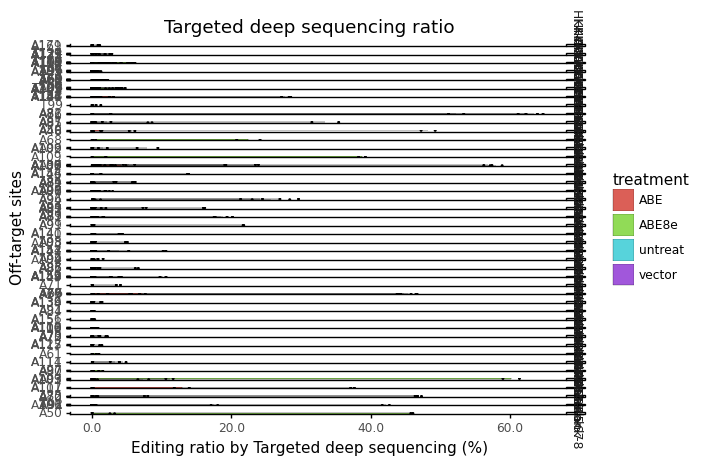

<ggplot: (2953980676051)>

In [189]:
# df = df_plot.head(100)
df = df_plot
fig = (
        p9.ggplot()
        + p9.geom_bar(
            data=df,
            mapping=p9.aes(x="mut_info", y="mut_ratio_mean", fill="treatment"),
            stat=p9.stats.stat_identity,
            position=p9.positions.position_dodge(
                width=0.9, preserve="total"  # Bar width
            ),
            color="black",
            size=0.1,
            raster=False,
        )
        + p9.geom_point(
            data=df,
            mapping=p9.aes(
                x="mut_info",
                y="mut_ratio",
                # fill="treatment",
                group="treatment",
            ),
            # color="black",
            position=p9.positions.position_dodge(
                width=0.9, preserve="total"  # Bar width
            ),
            size=0.2,
        )
        + p9.scale_x_discrete(name="Off-target sites")
        + p9.scale_y_continuous(
            name="Editing ratio by Targeted deep sequencing (%)",
            # breaks=np.arange(0, df.mut_ratio.max(), round(df.mut_ratio.max() / 10, 1)),
            labels=lambda L: ["%.1f" % v for v in L],
        )
        + p9.coord_flip()
        + p9.facet_grid("region_id~.", scales='free_y')
        + p9.theme_classic()
        # + p9.scale_fill_brewer(type="qualitative", palette="Set2")  # 画share old的时候注释掉这一行不然颜色不够用
        + p9.ggtitle("Targeted deep sequencing ratio")
    )
fig

In [190]:
p9.ggsave(
    fig,
    "2022-05-24_HEK4_barplot.pdf",
    height=df_plot.shape[0] * 0.05,
    width=4,
    limitsize=False,
)

/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 4 x 49.800000000000004 in image.
/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: 2022-05-24_HEK4_barplot.pdf
/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/plotnine/utils.py:371: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/plotnine/utils.py:371: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.


# 数据分布

In [191]:
df_plot

,region_id,relative_pos,treatment,rep,mut_info,mut_ratio,mut_ratio_mean
0,HK4-AOut-1,169,untreat,rep1,A169,0.001553,0.001553
1,HK4-AOut-1,169,ABE,rep1,A169,0.000777,0.002882
2,HK4-AOut-1,169,ABE,rep2,A169,0.004988,0.002882
3,HK4-AOut-1,169,ABE8e,rep2,A169,1.077381,0.967482
4,HK4-AOut-1,169,ABE8e,rep1,A169,0.857582,0.967482
...,...,...,...,...,...,...,...
991,HK4-Rank-38,97,ABE,rep2,A97,0.008032,0.008628
992,HK4-Rank-38,97,ABE8e,rep1,A97,0.097851,0.120104
993,HK4-Rank-38,97,ABE8e,rep2,A97,0.142357,0.120104
994,HK4-Rank-38,97,vector,rep1,A97,0.015885,0.015885


In [265]:
print('\nmut_ratio of bases%')
print(df_plot.query("(treatment != 'ABE') | (treatment == 'ABE' & mut_ratio > 0)")
      .groupby('treatment').mut_ratio.describe()
      [['count', 'mean', 'min', 'max', '25%', '50%', '75%']])

print('\nmut_ratio of regions%')
print(df_plot.query("(treatment != 'ABE') | (treatment == 'ABE' & mut_ratio > 0)")
      .groupby(['treatment', 'region_id']).mut_ratio.max()
      .reset_index()
      .groupby("treatment").mut_ratio.describe()
      [['count', 'mean', 'min', 'max', '25%', '50%', '75%']])
# .describe()[['count', 'mean', 'min', 'max', '25%', '50%', '75%']]


mut_ratio of bases%
           count      mean       min        max       25%       50%       75%
treatment                                                                    
ABE        305.0  1.175360  0.000357  53.341582  0.006891  0.020079  0.144313
ABE8e      332.0  7.692719  0.001817  64.736651  0.326330  1.037211  5.122441
untreat    166.0  0.074547  0.000000   2.054795  0.000779  0.005012  0.027918
vector     166.0  0.074968  0.000000   1.833227  0.001447  0.006613  0.020540

mut_ratio of regions%
           count       mean       min        max       25%       50%        75%
treatment                                                                      
ABE         43.0   3.814133  0.003892  53.341582  0.033701  0.113913   2.081784
ABE8e       44.0  17.680150  0.274181  64.736651  2.041269  6.405806  31.068325
untreat     44.0   0.132558  0.000000   2.054795  0.001624  0.008221   0.047759
vector      44.0   0.125940  0.000000   1.833227  0.002934  0.011630   0.037003


/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
/lustre1/chengqiyi_pkuhpc/zhaohn/0.apps/miniconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar fle

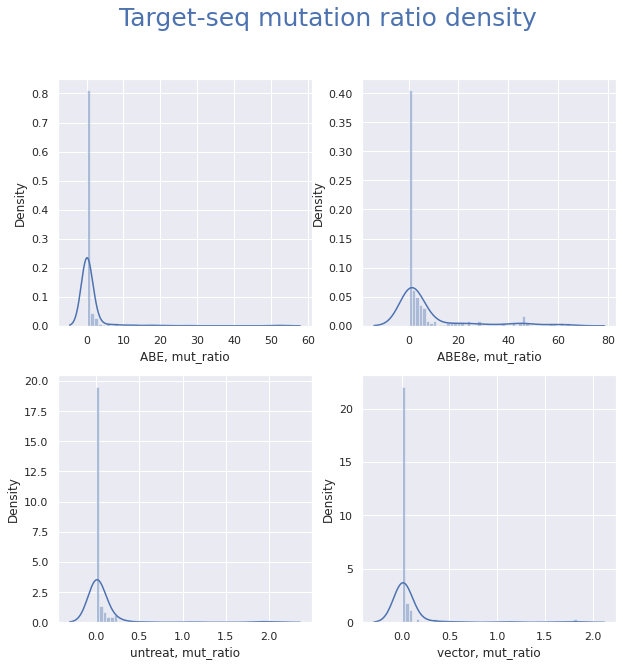

In [247]:
#设置画布尺寸
fig, ax = plt.subplots(2,2, figsize = [10,10])

#划分绘图区域
sns.distplot(df_plot.query("treatment == 'ABE'")['mut_ratio'], ax=ax[0, 0])
ax[0, 0].set_xlabel('ABE, mut_ratio')


sns.distplot(df_plot.query("treatment == 'ABE8e'")['mut_ratio'], ax=ax[0, 1])
ax[0, 1].set_xlabel('ABE8e, mut_ratio')
# plt.xticks(index,labels)
# plt.plot(ratio,'b-')

sns.distplot(df_plot.query("treatment == 'untreat'")['mut_ratio'], ax=ax[1, 0])
ax[1, 0].set_xlabel('untreat, mut_ratio')

sns.distplot(df_plot.query("treatment == 'vector'")['mut_ratio'], ax=ax[1, 1])
ax[1, 1].set_xlabel('vector, mut_ratio')


fig.suptitle('Target-seq mutation ratio density',fontsize=25,color='b')


plt.savefig('2022-05-28_density.pdf')
plt.show()